# Chapter 6 Companion Notebook: Machine Learning Fundamentals

This notebook reproduces the worked examples from Chapter 6 of *AI in Finance* (`chapter6.tex`): regression (with standard errors, confidence intervals, and p-values), gradient descent, classification, $K$-nearest neighbors, a maximum-margin support vector machine, a real (not just stylized) demonstration of overfitting and ridge regularization, model calibration, $K$-means clustering, and a neural network forward pass.

## 1. Regression: leverage vs. credit spread (Section 6.4)

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([2, 3, 4, 5, 6]).reshape(-1, 1)
y = np.array([120, 150, 210, 260, 300])

model = LinearRegression().fit(X, y)
print(f"Intercept (beta0): {model.intercept_:.1f}")
print(f"Slope (beta1):     {model.coef_[0]:.1f}")
print(f"R-squared:         {model.score(X, y):.4f}")

predicted_spread = model.predict([[4.5]])[0]
print(f"Predicted spread at leverage=4.5: {predicted_spread:.1f} bps")

Intercept (beta0): 20.0
Slope (beta1):     47.0
R-squared:         0.9915
Predicted spread at leverage=4.5: 231.5 bps


### Standard errors, confidence intervals, and p-values (Section 6.4.1)

How precisely is the slope $\hat\beta_1=47$ actually known?

In [2]:
from scipy import stats

x_vals = X.flatten().astype(float)
y_vals = y.astype(float)
n_reg = len(x_vals)
xbar_reg, ybar_reg = x_vals.mean(), y_vals.mean()

b1 = model.coef_[0]
b0 = model.intercept_
resid = y_vals - (b0 + b1 * x_vals)
sse = np.sum(resid ** 2)
dof_reg = n_reg - 2
sigma2_reg = sse / dof_reg

se_b1 = np.sqrt(sigma2_reg / np.sum((x_vals - xbar_reg) ** 2))
se_b0 = np.sqrt(sigma2_reg * (1 / n_reg + xbar_reg ** 2 / np.sum((x_vals - xbar_reg) ** 2)))

t_b1 = b1 / se_b1
t_b0 = b0 / se_b0
p_b1 = 2 * (1 - stats.t.cdf(abs(t_b1), dof_reg))
p_b0 = 2 * (1 - stats.t.cdf(abs(t_b0), dof_reg))
tcrit_reg = stats.t.ppf(0.975, dof_reg)
ci_b1 = (b1 - tcrit_reg * se_b1, b1 + tcrit_reg * se_b1)

print(f"SE(b1)={se_b1:.4f}, t={t_b1:.2f}, p={p_b1:.6f}")
print(f"95% CI for b1: ({ci_b1[0]:.2f}, {ci_b1[1]:.2f})")
print(f"SE(b0)={se_b0:.4f}, t={t_b0:.2f}, p={p_b0:.4f}")

SE(b1)=2.5166, t=18.68, p=0.000335
95% CI for b1: (38.99, 55.01)
SE(b0)=10.6771, t=1.87, p=0.1578


## 2. How models learn: gradient descent (Section 6.5)

Fit the same credit-spread regression using gradient descent from $\beta_0=\beta_1=0$, learning rate $\eta=0.01$, and check it converges to the closed-form OLS solution ($\beta_0=20$, $\beta_1=47$).

In [3]:
import pandas as pd

eta = 0.01
beta0_gd, beta1_gd = 0.0, 0.0
n_gd = len(x_vals)
checkpoints = {1, 2, 3, 10, 1_000, 10_000}
trajectory = []

for iteration in range(1, 10_001):
    y_hat = beta0_gd + beta1_gd * x_vals
    grad0 = (2 / n_gd) * np.sum(y_hat - y_vals)
    grad1 = (2 / n_gd) * np.sum((y_hat - y_vals) * x_vals)
    beta0_gd -= eta * grad0
    beta1_gd -= eta * grad1
    if iteration in checkpoints:
        trajectory.append((iteration, beta0_gd, beta1_gd))

traj_df = pd.DataFrame(trajectory, columns=['Iteration', 'beta0', 'beta1'])
print(traj_df.round(2).to_string(index=False))
print(f"\nClosed-form OLS: beta0={b0:.2f}, beta1={b1:.2f}")

 Iteration  beta0  beta1
         1   4.16  18.52
         2   6.76  30.04
         3   8.38  37.21
        10  11.05  48.55
      1000  18.91  47.24
     10000  20.00  47.00

Closed-form OLS: beta0=20.00, beta1=47.00


## 3. Classification: loan default and the confusion matrix (Section 6.6)

In [4]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

actual =    [1, 0, 1, 0, 0, 1, 0, 0, 1, 0]
predicted = [1, 0, 1, 1, 0, 1, 0, 0, 0, 0]

tn, fp, fn, tp = confusion_matrix(actual, predicted).ravel()
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"Accuracy:  {accuracy_score(actual, predicted):.2f}")
print(f"Precision: {precision_score(actual, predicted):.2f}")
print(f"Recall:    {recall_score(actual, predicted):.2f}")
print(f"F1:        {f1_score(actual, predicted):.2f}")
fpr = fp / (fp + tn)
print(f"False positive rate: {fpr:.3f}")

TP=3, FP=1, FN=1, TN=5
Accuracy:  0.80
Precision: 0.75
Recall:    0.75
F1:        0.75
False positive rate: 0.167


## 4. $K$-nearest neighbors (Section 6.7)

Classify a new applicant (debt/income=28%, credit history=4 years) using the 6-applicant loan dataset, with $k=3$.

In [5]:
loan_data = pd.DataFrame({
    'Applicant': list('ABCDEF'),
    'DebtIncome': [35, 20, 40, 15, 30, 18],
    'CreditHistory': [2, 8, 1, 10, 3, 7],
    'Outcome': ['Default', 'No default', 'Default', 'No default', 'Default', 'No default'],
})

query = np.array([28, 4])
loan_data['Distance'] = np.sqrt(
    (query[0] - loan_data['DebtIncome']) ** 2 + (query[1] - loan_data['CreditHistory']) ** 2
)
sorted_data = loan_data.sort_values('Distance')
print(sorted_data.round(2).to_string(index=False))

k = 3
nearest_k = sorted_data.head(k)
vote = nearest_k['Outcome'].value_counts()
print(f"\n{k}-NN vote:\n{vote}")
print(f"Predicted class: {vote.idxmax()}")

Applicant  DebtIncome  CreditHistory    Outcome  Distance
        E          30              3    Default      2.24
        A          35              2    Default      7.28
        B          20              8 No default      8.94
        F          18              7 No default     10.44
        C          40              1    Default     12.37
        D          15             10 No default     14.32

3-NN vote:
Outcome
Default       2
No default    1
Name: count, dtype: int64
Predicted class: Default


## 4b. Support vector machine: maximum-margin hyperplane (Section 6.8)

Four points on a single feature, perfectly separable: high-risk at $x=1,2$; low-risk at $x=4,5$. Verify the hand-computed hyperplane ($w=1$, $b=-3$) against scikit-learn's linear SVM, and confirm the support vectors.

In [6]:
from sklearn.svm import SVC

X_svm = np.array([[1.0], [2.0], [4.0], [5.0]])
y_svm = np.array([-1, -1, 1, 1])

svm = SVC(kernel='linear', C=1e6)  # large C approximates a hard-margin SVM
svm.fit(X_svm, y_svm)

w_fit = svm.coef_[0][0]
b_fit = svm.intercept_[0]
boundary = -b_fit / w_fit

print(f"Fitted w: {w_fit:.4f}, b: {b_fit:.4f}")
print(f"Decision boundary (w*x+b=0) at x = {boundary:.4f}")
print(f"Support vectors: {svm.support_vectors_.ravel()}")
print(f"Margin width (2/|w|): {2/abs(w_fit):.4f}")

Fitted w: 1.0000, b: -3.0000
Decision boundary (w*x+b=0) at x = 3.0000
Support vectors: [2. 4.]
Margin width (2/|w|): 2.0000


## 5. A real overfitting demonstration (extends Section 6.9)

The chapter presents a *stylized* table of training vs. test error as model complexity grows (Table 6.5). Here we generate that same qualitative pattern from actual data: fit polynomials of increasing degree to a noisy nonlinear function, and track train vs. held-out test error.

In [7]:
rng = np.random.default_rng(42)
n_train, n_test = 25, 200

def true_function(x):
    return 3 + 2 * x - 0.5 * x**2

x_train = rng.uniform(-3, 3, n_train)
y_train = true_function(x_train) + rng.normal(0, 3, n_train)
x_test = rng.uniform(-3, 3, n_test)
y_test = true_function(x_test) + rng.normal(0, 3, n_test)

In [8]:
from numpy.polynomial import polynomial as P

degrees = [1, 2, 3, 5, 9, 15]
results = []
for deg in degrees:
    coefs = np.polyfit(x_train, y_train, deg)
    train_pred = np.polyval(coefs, x_train)
    test_pred = np.polyval(coefs, x_test)
    train_mse = np.mean((y_train - train_pred) ** 2)
    test_mse = np.mean((y_test - test_pred) ** 2)
    results.append((deg, train_mse, test_mse))

import pandas as pd
results_df = pd.DataFrame(results, columns=['Degree', 'Train MSE', 'Test MSE'])
results_df.round(2)

,Degree,Train MSE,Test MSE
0,1,5.79,12.15
1,2,4.14,9.30
2,3,2.16,12.66
3,5,2.12,11.92
4,9,1.70,31.11
5,15,0.50,242088.88


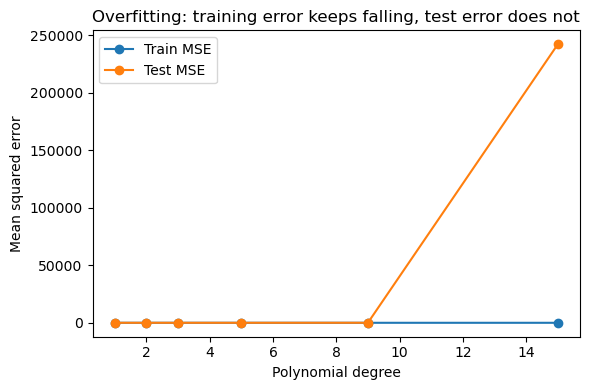

Test-error-minimizing degree: 2 (true function is degree 2, so this should be close to 2)


In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(results_df['Degree'], results_df['Train MSE'], marker='o', label='Train MSE')
ax.plot(results_df['Degree'], results_df['Test MSE'], marker='o', label='Test MSE')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel('Mean squared error')
ax.set_title('Overfitting: training error keeps falling, test error does not')
ax.legend()
plt.tight_layout()
plt.show()

best_degree = results_df.loc[results_df['Test MSE'].idxmin(), 'Degree']
print(f"Test-error-minimizing degree: {best_degree:.0f} "
      f"(true function is degree 2, so this should be close to 2)")

This is the same qualitative pattern as the stylized Table 6.5 in the text, produced from actual random data: training error falls monotonically as degree increases, while test error is minimized at a modest degree and then rises again as the model overfits the training noise.

## 6. Ridge regularization on a high-degree polynomial

Section 6.9 introduces ridge regression as a way to control the high-variance, high-degree model. We refit the degree-15 polynomial with an L2 penalty and compare test error to the unregularized version.

In [10]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

for alpha in [0, 1, 10, 100]:
    model = make_pipeline(PolynomialFeatures(15), Ridge(alpha=alpha))
    model.fit(x_train.reshape(-1, 1), y_train)
    test_mse = np.mean((y_test - model.predict(x_test.reshape(-1, 1))) ** 2)
    label = 'alpha=0 (OLS)' if alpha == 0 else f'alpha={alpha}'
    print(f"{label:15s} -> test MSE: {test_mse:.2f}")

alpha=0 (OLS)   -> test MSE: 242088.88
alpha=1         -> test MSE: 1005.11
alpha=10        -> test MSE: 1131.01
alpha=100       -> test MSE: 1195.94


As the ridge penalty `alpha` increases from 0, test error typically falls before rising again at very high penalties, illustrating the bias-variance tradeoff directly: a little regularization reduces variance faster than it adds bias, but too much regularization eventually costs more in bias than it saves in variance.

## 7. Model calibration (Section 6.12)

A model predicts a 20% default probability for a group of 50 borrowers. Compare two scenarios: one where the model is well calibrated, one where it is not, even though ranking ability (AUC) could be identical in both.

In [11]:
n_borrowers = 50
predicted_prob = 0.20
expected_defaults = predicted_prob * n_borrowers
print(f"Expected defaults if well calibrated: {expected_defaults:.0f}")

for actual_defaults in [10, 2]:
    observed_rate = actual_defaults / n_borrowers
    print(f"Actual defaults={actual_defaults} -> observed rate={observed_rate:.0%}, "
          f"{'well calibrated' if abs(observed_rate - predicted_prob) < 0.02 else 'poorly calibrated'}")

Expected defaults if well calibrated: 10
Actual defaults=10 -> observed rate=20%, well calibrated
Actual defaults=2 -> observed rate=4%, poorly calibrated


## 8. $K$-means clustering (Section 6.17)

Four firms described by (leverage, profit margin), both scaled to [0,1]. Initialize centers at $F_1$ and $F_4$ and run one update.

In [12]:
firms = np.array([
    [0.20, 0.30],  # F1
    [0.30, 0.25],  # F2
    [0.80, 0.05],  # F3
    [0.90, 0.10],  # F4
])

centers = np.array([firms[0], firms[3]])  # initialize at F1 and F4

def assign_and_update(points, centers):
    dists = np.linalg.norm(points[:, None, :] - centers[None, :, :], axis=2)
    assignments = dists.argmin(axis=1)
    new_centers = np.array([points[assignments == k].mean(axis=0) for k in range(len(centers))])
    return assignments, new_centers

assignments, new_centers = assign_and_update(firms, centers)
print(f"Assignments (0=cluster1, 1=cluster2): {assignments}")
print(f"Updated centers:\n{new_centers.round(4)}")

# Check convergence: re-assign with updated centers
assignments2, new_centers2 = assign_and_update(firms, new_centers)
print(f"Converged: {np.array_equal(assignments, assignments2)}")

Assignments (0=cluster1, 1=cluster2): [0 0 1 1]
Updated centers:
[[0.25  0.275]
 [0.85  0.075]]
Converged: True


## 9. Neural network forward pass (Section 6.18)

Two inputs, a hidden layer with two ReLU units, and a single sigmoid output.

In [13]:
W1 = np.array([[0.4, -0.2], [0.1, 0.3]])
b1_nn = np.array([0.05, -0.1])
W2 = np.array([0.6, -0.5])
b2_nn = 0.1

x_input = np.array([1.0, 0.5])

def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

pre_activation_hidden = W1 @ x_input + b1_nn
h = relu(pre_activation_hidden)
print(f"Hidden pre-activation: {pre_activation_hidden.round(4)}")
print(f"Hidden activation (ReLU): {h.round(4)}")

pre_activation_output = W2 @ h + b2_nn
y_hat_nn = sigmoid(pre_activation_output)
print(f"Output pre-activation: {pre_activation_output:.4f}")
print(f"Final prediction (sigmoid): {y_hat_nn:.4f}")

Hidden pre-activation: [0.35 0.15]
Hidden activation (ReLU): [0.35 0.15]
Output pre-activation: 0.2350
Final prediction (sigmoid): 0.5585


## Exercises (match Chapter 6, Suggested Exercises)

1. Verify by hand that the regression slope and intercept above equal 47 and 20.
2. Add a sixth observation (leverage=7, spread=500) to the regression data and refit; how much do the slope and R-squared change?
3. Lower the classification threshold so applicant 5 is also predicted to default, and recompute all four classification metrics.

In [14]:
# Exercise 2: add an outlier-like sixth observation
X6 = np.array([2, 3, 4, 5, 6, 7]).reshape(-1, 1)
y6 = np.array([120, 150, 210, 260, 300, 500])
model6 = LinearRegression().fit(X6, y6)
print(f"With 6th point -- slope: {model6.coef_[0]:.2f}, R^2: {model6.score(X6, y6):.4f}")

# Exercise 3: lower the threshold
predicted_ex3 = [1, 0, 1, 1, 1, 1, 0, 0, 0, 0]  # applicant 5 now flagged too
print(f"Accuracy:  {accuracy_score(actual, predicted_ex3):.2f}")
print(f"Precision: {precision_score(actual, predicted_ex3):.2f}")
print(f"Recall:    {recall_score(actual, predicted_ex3):.2f}")
print(f"F1:        {f1_score(actual, predicted_ex3):.2f}")

With 6th point -- slope: 68.57, R^2: 0.8816
Accuracy:  0.70
Precision: 0.60
Recall:    0.75
F1:        0.67
